Dataset loaded: (121916, 22)

Original target distribution (rows, distress):
distress
0    121179
1       737
Name: count, dtype: int64

Number of firms by class BEFORE balancing:
Distressed firms : 735
Healthy firms    : 7785

Number of firms by class AFTER firm-level balancing:
Distressed firms kept : 735
Healthy firms kept    : 2205

Row-level target distribution in balanced dataset:
distress
0    38370
1      737
Name: count, dtype: int64

Selected features: ['roa', 'ebitda_margin', 'debt_ratio', 'total_debt_to_equity', 'current_ratio', 'cash_ratio', 'interest_coverage', 'cfo_margin', 'free_cash_flow', 'asset_turnover', 'sales_growth', 'asset_growth', 'book_to_market', 'price_to_book', 'working_capital_to_assets', 'retained_earnings_to_assets']

Train/test sizes after firm-level balancing and temporal split:
Train: (24008, 16)
Test : (15099, 16)

Train target distribution (rows):
distress
0    23476
1      532
Name: count, dtype: int64

Test target distribution (rows):
distress
0  

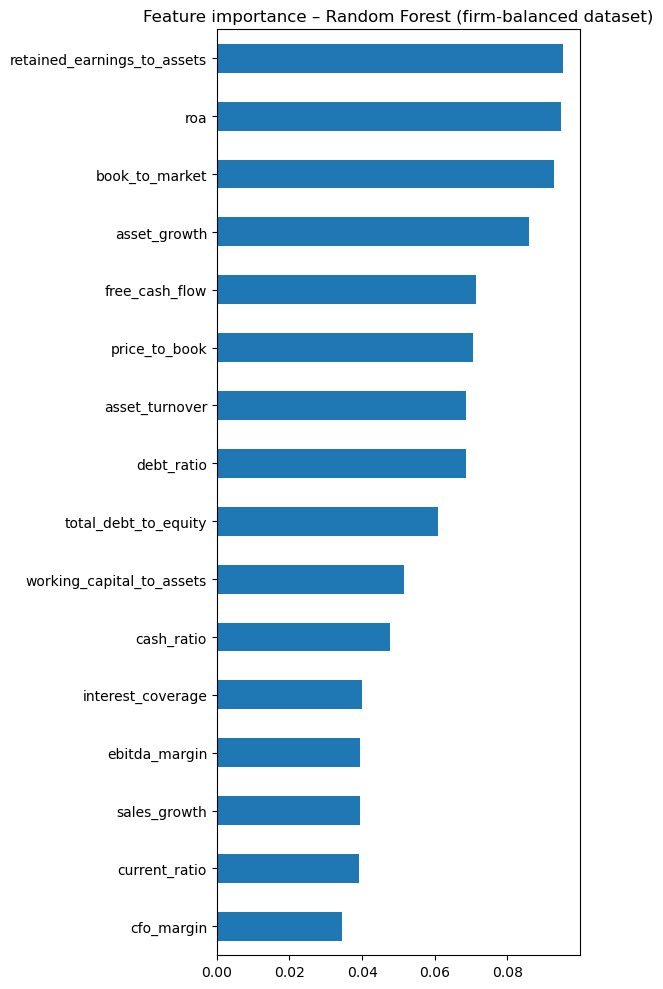

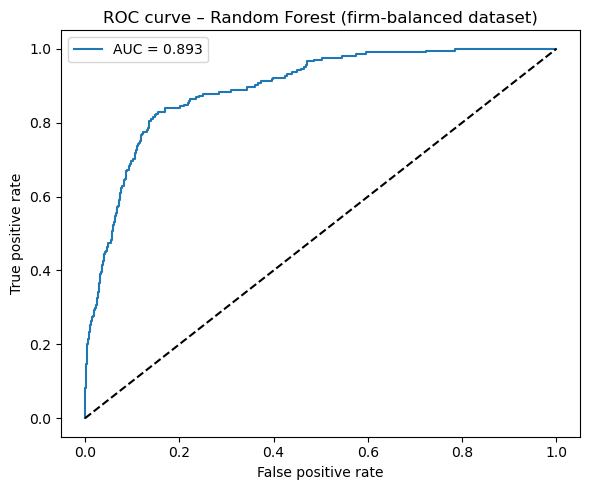

In [6]:
# ============================================================
# 0. Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1. Load cleaned + scaled dataset
# ============================================================
data_path = "../data/processed/compustat_kpis_clean_scaled.csv"
df = pd.read_csv(data_path)
print("Dataset loaded:", df.shape)

# Keep only rows with year info
df = df.dropna(subset=["fyear"])
df["fyear"] = df["fyear"].astype(int)

# ============================================================
# 2. Build target variable from dlrsn
#    distress = 1 if dlrsn in {2,3}, else 0
# ============================================================
df["distress"] = df["dlrsn"].isin([2, 3]).astype(int)

print("\nOriginal target distribution (rows, distress):")
print(df["distress"].value_counts().rename("count"))

# ============================================================
# 3. Balance at the FIRM level (gvkey)
#    - A firm is "distressed" if it has at least one row with distress = 1
#    - A firm is "healthy" if all rows have distress = 0
#    - We keep ALL distressed firms + 3x as many healthy firms (by gvkey)
# ============================================================

# Distressed firms: at least one observation with distress = 1
distressed_firms = df.loc[df["distress"] == 1, "gvkey"].unique()

# Healthy firms: gvkey that never appear with distress = 1
all_firms = df["gvkey"].unique()
healthy_firms = np.setdiff1d(all_firms, distressed_firms)

n_distress_firms = len(distressed_firms)
n_healthy_firms = len(healthy_firms)

print("\nNumber of firms by class BEFORE balancing:")
print(f"Distressed firms : {n_distress_firms}")
print(f"Healthy firms    : {n_healthy_firms}")

# Ratio: 3 healthy firms for 1 distressed firm
ratio_firms = 3
n_healthy_keep = min(n_healthy_firms, ratio_firms * n_distress_firms)

# Randomly sample healthy gvkeys
np.random.seed(42)
healthy_sample_firms = np.random.choice(
    healthy_firms,
    size=n_healthy_keep,
    replace=False
)

# Build balanced dataset: all rows from distressed firms + sampled healthy firms
mask_balanced = df["gvkey"].isin(distressed_firms) | df["gvkey"].isin(healthy_sample_firms)
df_balanced = df[mask_balanced].copy()

# Shuffle rows
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nNumber of firms by class AFTER firm-level balancing:")
print("Distressed firms kept :", len(distressed_firms))
print("Healthy firms kept    :", len(healthy_sample_firms))

print("\nRow-level target distribution in balanced dataset:")
print(df_balanced["distress"].value_counts().rename("count"))

# ============================================================
# 4. Select KPIs as features
# ============================================================
feature_cols = [
    "roa", "ebitda_margin", "debt_ratio", "total_debt_to_equity",
    "current_ratio", "cash_ratio", "interest_coverage",
    "cfo_margin", "free_cash_flow", "asset_turnover",
    "sales_growth", "asset_growth",
    "book_to_market", "price_to_book",
    "working_capital_to_assets", "retained_earnings_to_assets",
]

feature_cols = [c for c in feature_cols if c in df_balanced.columns]

print("\nSelected features:", feature_cols)

X = df_balanced[feature_cols]
y = df_balanced["distress"]

# ============================================================
# 5. Temporal Split (train ≤ 2015, test ≥ 2016)
# ============================================================
train_df = df_balanced[df_balanced["fyear"] <= 2015]
test_df  = df_balanced[df_balanced["fyear"] >= 2016]

X_train = train_df[feature_cols]
y_train = train_df["distress"]

X_test = test_df[feature_cols]
y_test = test_df["distress"]

print("\nTrain/test sizes after firm-level balancing and temporal split:")
print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain target distribution (rows):")
print(y_train.value_counts().rename("count"))
print("\nTest target distribution (rows):")
print(y_test.value_counts().rename("count"))

# ============================================================
# 6. Random Forest model
# ============================================================
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight=None,  # dataset déjà équilibré au niveau des firmes
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ============================================================
# 7. Predictions – default threshold 0.5
# ============================================================
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# ============================================================
# 8. Evaluation
# ============================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n=== Random Forest – Firm-balanced dataset, Temporal Test 2016–2023 ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

# ============================================================
# 9. Threshold tuning (0.30 à 0.70)
# ============================================================
thresholds = np.arange(0.3, 0.71, 0.1)  # 0.30, 0.40, 0.50, 0.60, 0.70
print("\nThreshold tuning (firm-balanced RF, 0.30–0.70):")
for thr in thresholds:
    y_thr = (y_proba >= thr).astype(int)
    acc_thr = accuracy_score(y_test, y_thr)
    prec_thr = precision_score(y_test, y_thr, zero_division=0)
    rec_thr = recall_score(y_test, y_thr, zero_division=0)
    f1_thr = f1_score(y_test, y_thr, zero_division=0)
    print(f"thr={thr:.2f}  Acc={acc_thr:.3f}  Prec={prec_thr:.3f}  Rec={rec_thr:.3f}  F1={f1_thr:.3f}")

# ============================================================
# 10. Feature importance
# ============================================================
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(6, 10))
importances.plot(kind="barh")
plt.title("Feature importance – Random Forest (firm-balanced dataset)")
plt.tight_layout()
plt.show()

# ============================================================
# 11. ROC curve
# ============================================================
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve – Random Forest (firm-balanced dataset)")
plt.legend()
plt.tight_layout()
plt.show()
